In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
df_raw = pd.read_csv('/content/archive (1).zip')
df = df_raw.copy()

print(f"Shape: {df.shape}")
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


##🔹Data Exploration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [col for col in df.columns
                 if df[col].nunique() == 1]
print("Constant columns:", constant_cols)

Missing values:
 0
Duplicate rows: 0
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [ ]:
print(f"shape:  {df.shape}")

shape:  (1470, 35)


In [ ]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=cols_to_drop)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (1470, 31)


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_report = {}

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        outlier_report[col] = n_outliers

outlier_report

{'MonthlyIncome': np.int64(114),
 'NumCompaniesWorked': np.int64(52),
 'PerformanceRating': np.int64(226),
 'StockOptionLevel': np.int64(85),
 'TotalWorkingYears': np.int64(63),
 'TrainingTimesLastYear': np.int64(238),
 'YearsAtCompany': np.int64(104),
 'YearsInCurrentRole': np.int64(21),
 'YearsSinceLastPromotion': np.int64(107),
 'YearsWithCurrManager': np.int64(14)}

In [ ]:

df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition_Flag'].value_counts()


,count
Attrition_Flag,
0,1233
1,237


In [ ]:
df.shape

(1470, 32)

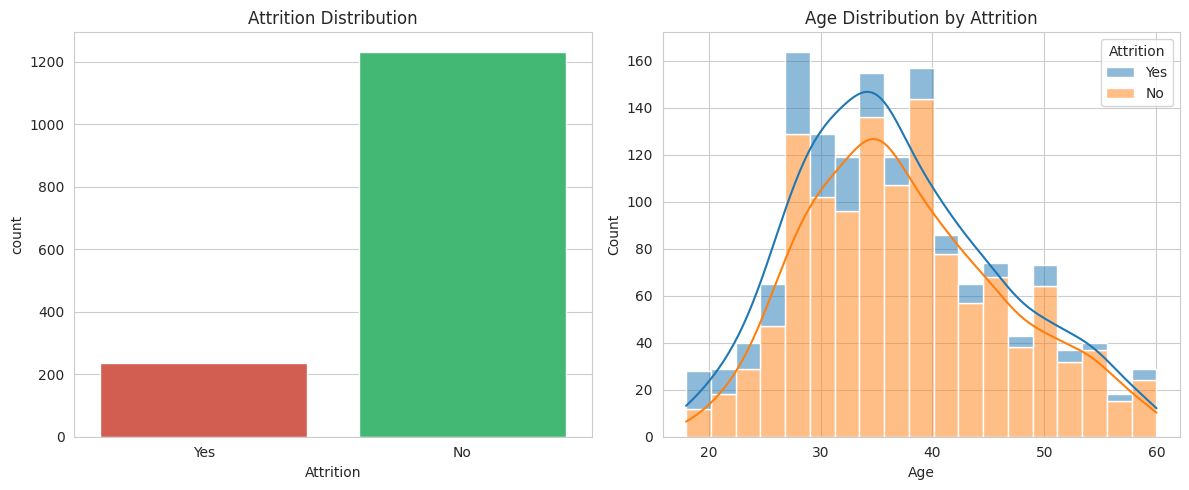

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Attrition', hue='Attrition', legend=False,
              palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Attrition Distribution')

sns.histplot(data=df, x='Age', hue='Attrition', kde=True, multiple='stack', ax=axes[1])
axes[1].set_title('Age Distribution by Attrition')

plt.tight_layout()
plt.show()

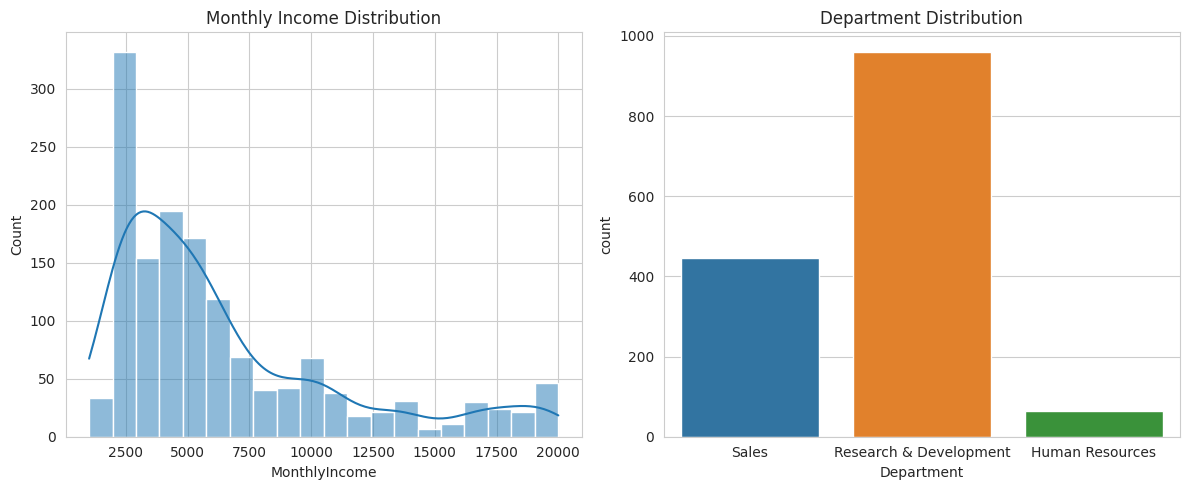

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='MonthlyIncome', kde=True, ax=axes[0])
axes[0].set_title('Monthly Income Distribution')

sns.countplot(data=df, x='Department', hue='Department', legend=False, ax=axes[1])
axes[1].set_title('Department Distribution')

plt.tight_layout()
plt.show()

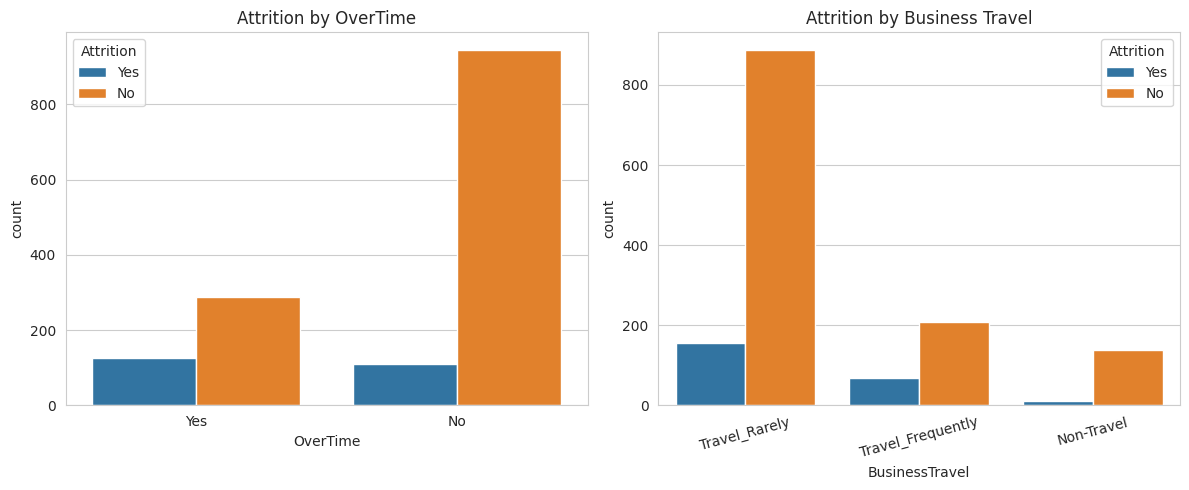

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0])
axes[0].set_title('Attrition by OverTime')

sns.countplot(data=df, x='BusinessTravel', hue='Attrition', ax=axes[1])
axes[1].set_title('Attrition by Business Travel')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('OverTime')['Attrition_Flag'].mean()


,Attrition_Flag
OverTime,
No,0.104364
Yes,0.305288


In [ ]:

df.groupby('BusinessTravel')['Attrition_Flag'].mean()

,Attrition_Flag
BusinessTravel,
Non-Travel,0.080000
Travel_Frequently,0.249097
Travel_Rarely,0.149569


In [ ]:
print(df.groupby('OverTime')['Attrition_Flag'].mean())
print(df.groupby('BusinessTravel')['Attrition_Flag'].mean())

OverTime
No     0.104364
Yes    0.305288
Name: Attrition_Flag, dtype: float64
BusinessTravel
Non-Travel           0.080000
Travel_Frequently    0.249097
Travel_Rarely        0.149569
Name: Attrition_Flag, dtype: float64


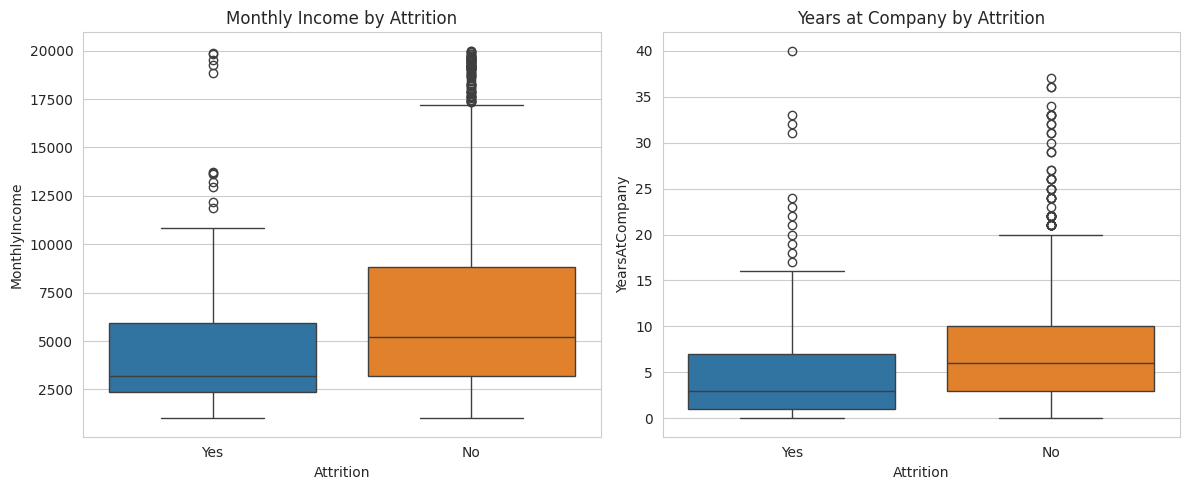

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', legend=False, ax=axes[0])
axes[0].set_title('Monthly Income by Attrition')

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', hue='Attrition', legend=False, ax=axes[1])
axes[1].set_title('Years at Company by Attrition')

plt.tight_layout()
plt.show()

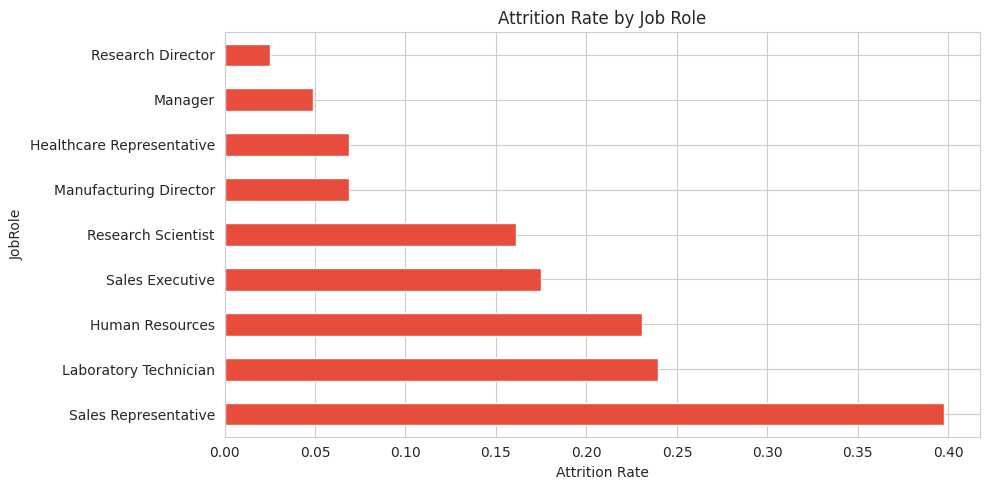

In [ ]:
role_rate = df.groupby('JobRole')['Attrition_Flag'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
role_rate.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Attrition Rate by Job Role')
ax.set_xlabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('JobSatisfaction')['Attrition_Flag'].mean()

,Attrition_Flag
JobSatisfaction,
1,0.228374
2,0.164286
3,0.165158
4,0.113290


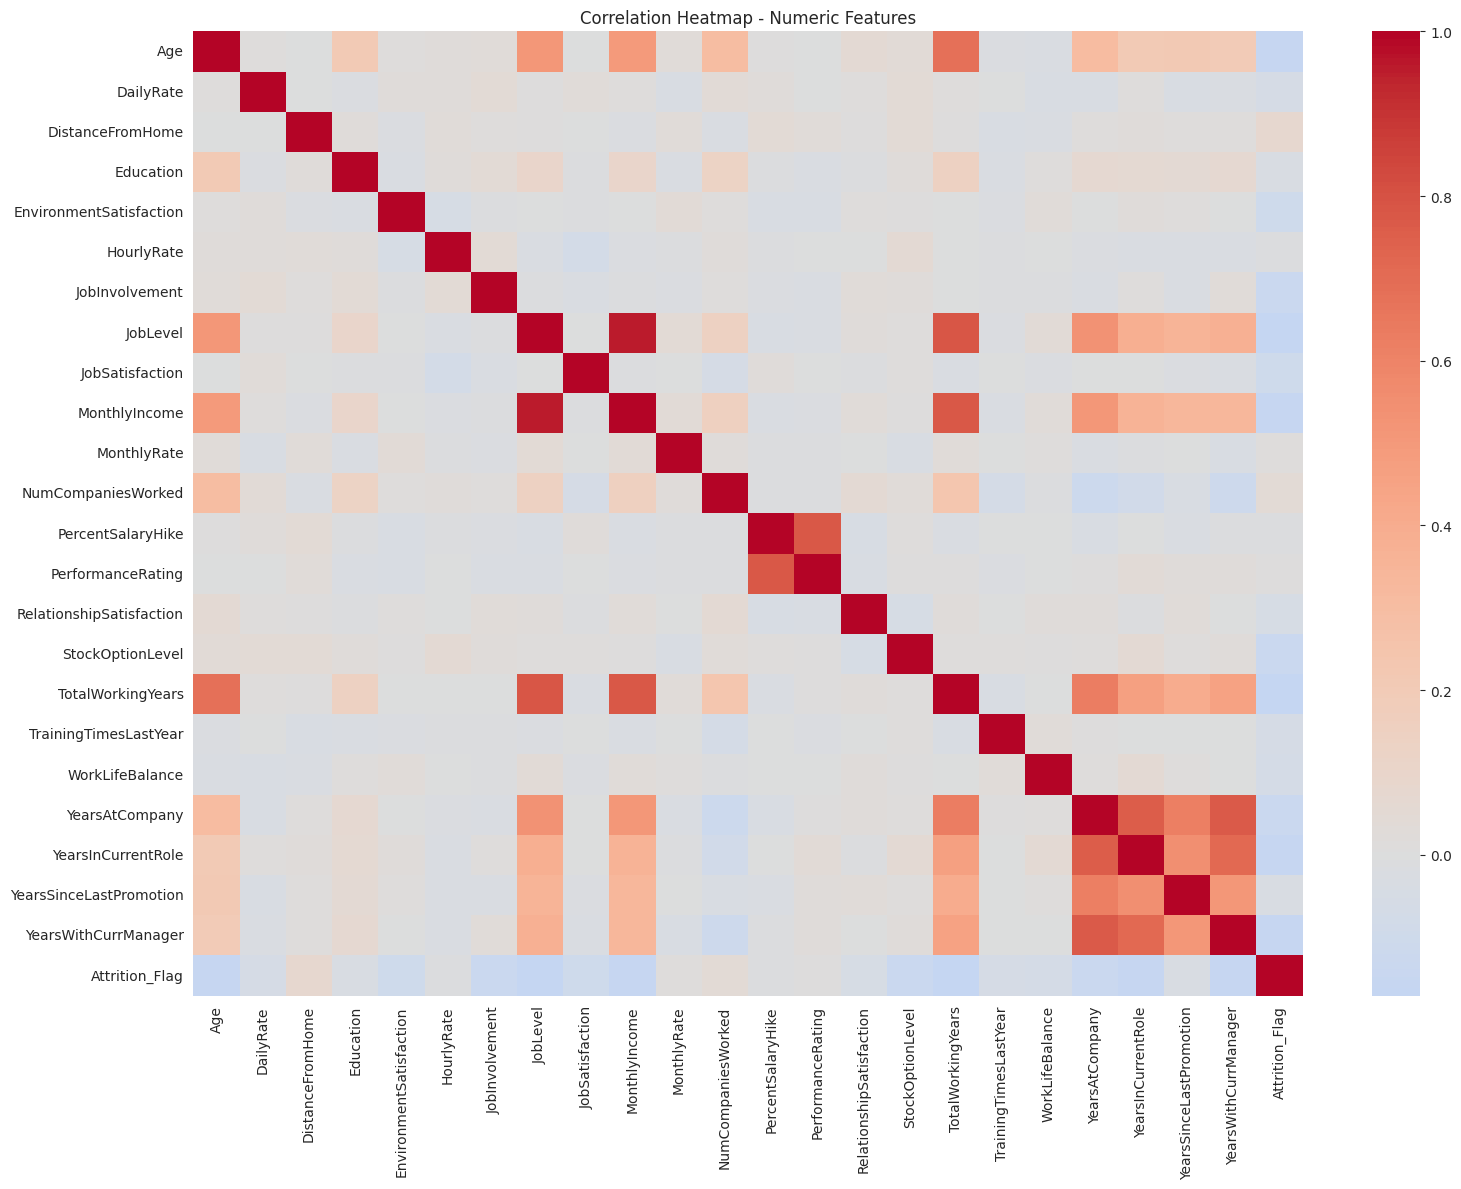

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
target_corr = corr['Attrition_Flag'].drop('Attrition_Flag').sort_values(key=abs, ascending=False)
target_corr.head(10)

,Attrition_Flag
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


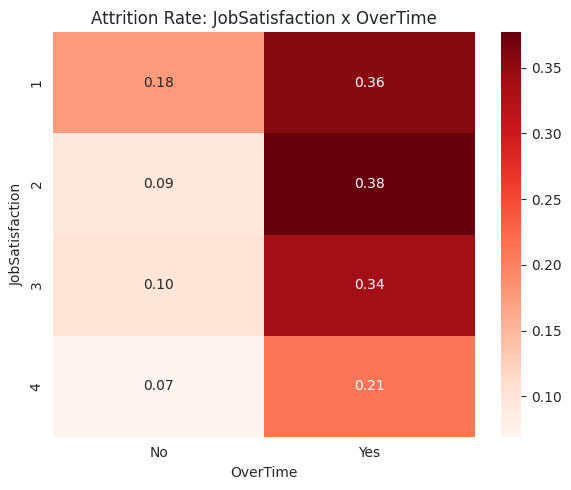

In [ ]:
pivot = df.pivot_table(index='JobSatisfaction', columns='OverTime',
                        values='Attrition_Flag', aggfunc='mean')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds', ax=ax)
ax.set_title('Attrition Rate: JobSatisfaction x OverTime')
plt.tight_layout()
plt.show()

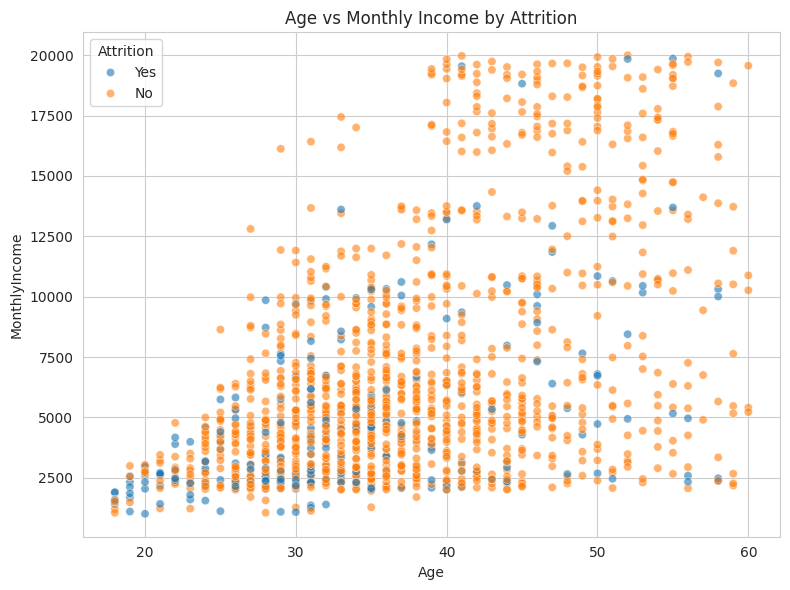

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition', alpha=0.6, ax=ax)
ax.set_title('Age vs Monthly Income by Attrition')
plt.tight_layout()
plt.show()

##📛 Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.drop(columns=['Attrition'])

# Binary
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Ordinal
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

# One-Hot
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [ ]:
X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 3. HistGradientBoosting (XGBoost alternative)
hgb = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)

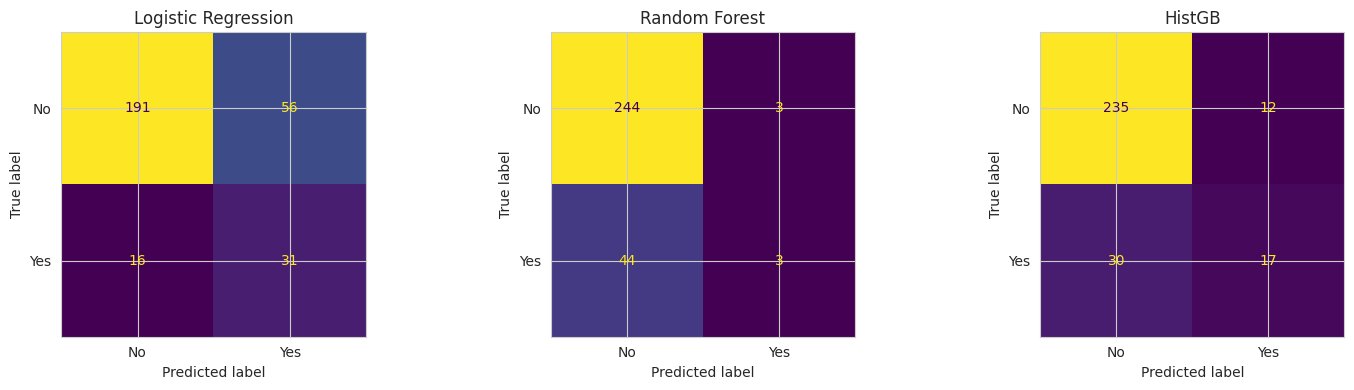

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'HistGB': (hgb, X_test)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, Xt)) in zip(axes, models.items()):
    pred = model.predict(Xt)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

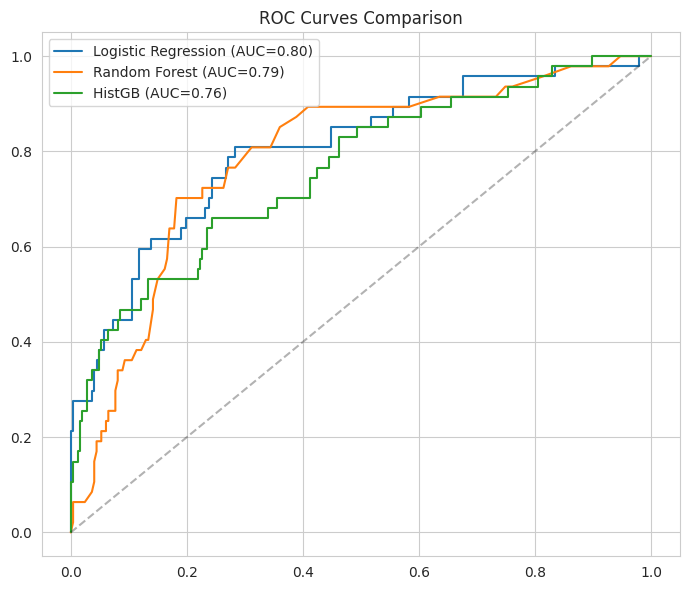

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, Xt) in models.items():
    proba = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curves Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'C': [0.01, 0.1, 0.5, 1, 5, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid, scoring='f1', cv=cv, n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_lr = grid.best_estimator_
pred_best_lr = best_lr.predict(X_test_scaled)
print(classification_report(y_test, pred_best_lr))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.38      0.70      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.79       294



In [ ]:
from sklearn.metrics import precision_recall_curve

proba_hgb = hgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_hgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

pred_hgb_tuned = (proba_hgb >= best_threshold).astype(int)
print(classification_report(y_test, pred_hgb_tuned))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       247
           1       0.51      0.47      0.49        47

    accuracy                           0.84       294
   macro avg       0.71      0.69      0.70       294
weighted avg       0.84      0.84      0.84       294



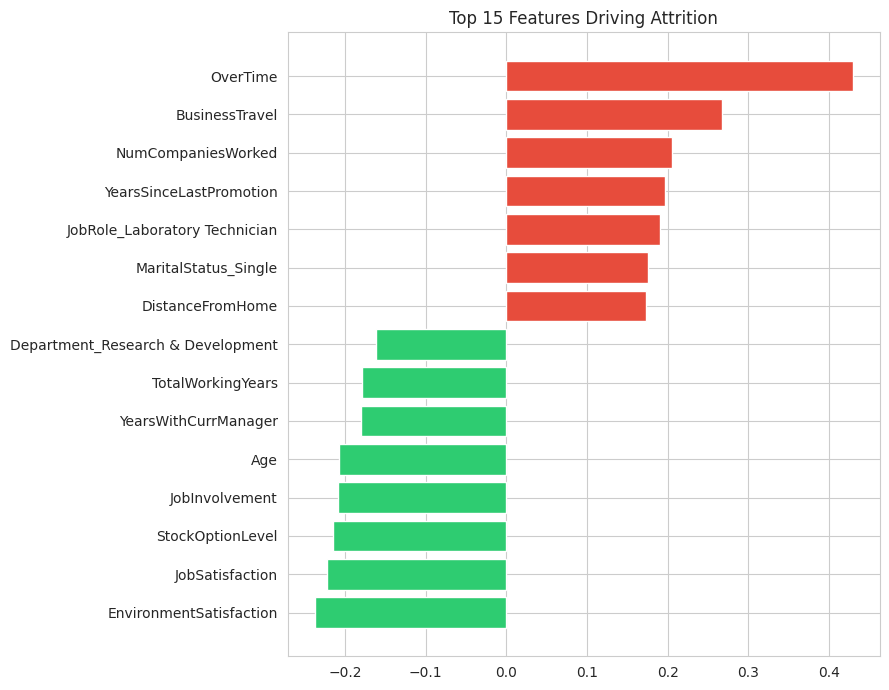

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top15 = coef_df.head(15).sort_values('Coefficient')
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top15['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15['Feature'], top15['Coefficient'], color=colors)
ax.set_title('Top 15 Features Driving Attrition')
plt.tight_layout()
plt.show()

In [ ]:
df.to_excel("HR_Cleaned.xlsx", index=False)

In [ ]:
df['Attrition_Flag'].sum()

np.int64(237)